# 🤖 Machine Learning – Análisis de Indicadores del World Bank

Este notebook realiza:
- Exploración de datos
- Regresión lineal
- Random Forest
- Clustering K-Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

## Cargar datos

In [2]:
# ejemplo de dataset
data = {
    'year':[2015,2016,2017,2018,2019,2020,2021,2022],
    'gdp_per_capita':[6000,6200,6400,6600,6800,6500,7000,7200],
    'population':[48,49,49.5,50,50.5,51,51.5,52]
}

df = pd.DataFrame(data)
df

,year,gdp_per_capita,population
0,2015,6000,48.0
1,2016,6200,49.0
2,2017,6400,49.5
3,2018,6600,50.0
4,2019,6800,50.5
5,2020,6500,51.0
6,2021,7000,51.5
7,2022,7200,52.0


## Visualización

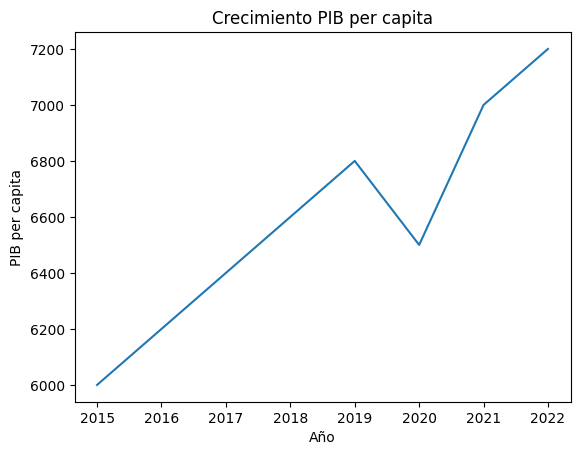

In [3]:
plt.plot(df['year'], df['gdp_per_capita'])
plt.xlabel("Año")
plt.ylabel("PIB per capita")
plt.title("Crecimiento PIB per capita")
plt.show()

## Modelo de Regresión Lineal

In [4]:
X = df[['year']]
y = df['gdp_per_capita']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test,pred))
print("R2:", r2_score(y_test,pred))

MSE: 75560.0
R2: -2.3582222222222224


## Random Forest

In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("MSE RF:", mean_squared_error(y_test,pred_rf))
print("R2 RF:", r2_score(y_test,pred_rf))

MSE RF: 61316.0
R2 RF: -1.7251555555555558


## Clustering K-Means

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['gdp_per_capita','population']])
df

,year,gdp_per_capita,population,cluster
0,2015,6000,48.0,0
1,2016,6200,49.0,0
2,2017,6400,49.5,0
3,2018,6600,50.0,0
4,2019,6800,50.5,1
5,2020,6500,51.0,0
6,2021,7000,51.5,1
7,2022,7200,52.0,1
